In [1]:

# For Data manipulation
import pandas as pd
import numpy as np

# For Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# For Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# For Displaying all columns instead of ...
pd.set_option('display.max_columns', None)


In [4]:

df = pd.read_csv("/content/drive/MyDrive/14 days of ML/TelecoChurn_DT+RF_Day5/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
display(df.head())
print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


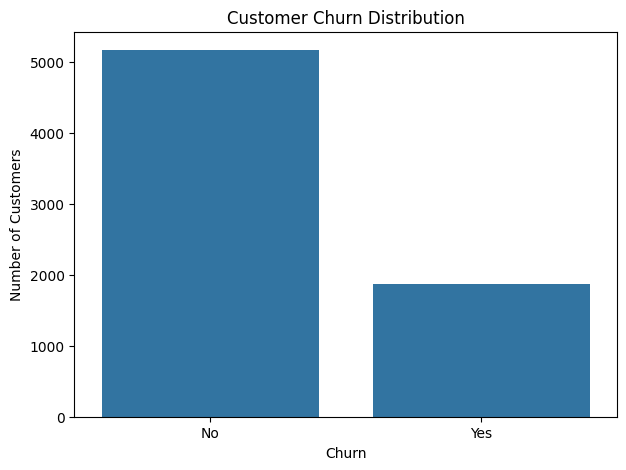

In [5]:
# Count customers in each churn category
churn_counts = df['Churn'].value_counts()
print("Churn Counts:")
print(churn_counts)

# Calculate percentage distribution
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
print("\nChurn Percentage:")
print(churn_percentage)

# Visualize churn distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [6]:
# Checking the current data type
print("Before conversion:")
print(df['TotalCharges'].dtype)
# Finding blank/whitespace values
blank_total_charges = df['TotalCharges'].astype(str).str.strip().eq('').sum()
print("\nBlank/whitespace values in TotalCharges:", blank_total_charges)

Before conversion:
object

Blank/whitespace values in TotalCharges: 11


In [7]:
# Converting Total Charges to numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Checking the new data type
print("Data type after conversion:")
print(df['TotalCharges'].dtype)

# Checking missing values created after conversion
print("\nMissing values in TotalCharges:")
print(df['TotalCharges'].isnull().sum())

Data type after conversion:
float64

Missing values in TotalCharges:
11


In [8]:
# Displaying the rows where TotalCharges is missing
missing_total_charges = df[df['TotalCharges'].isnull()]
display(
    missing_total_charges[
        ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
    ]
)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [9]:
# Replacing the missing TotalCharges values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verifing that no missing values remain
print("Missing TotalCharges after handling:")
print(df['TotalCharges'].isnull().sum())

# Verifing the data type
print("\nTotalCharges data type:")
print(df['TotalCharges'].dtype)

Missing TotalCharges after handling:
0

TotalCharges data type:
float64


In [10]:
# Checking the missing values in every column
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)
print("\nTotal Missing Values in Dataset:")
print(missing_values.sum())

Missing Values in Each Column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total Missing Values in Dataset:
0


In [11]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical Columns:")
print(numerical_columns)
print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [12]:
# Separate features and target
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Features shape: (7043, 19)
Target shape: (7043,)

Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target:
Churn


In [13]:
# Identify categorical columns in X
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:")
print(categorical_features)
# One-Hot Encode categorical features
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)
print("\nOriginal X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

print("\nEncoded feature columns:")
print(X_encoded.columns.tolist())

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Original X shape: (7043, 19)
Encoded X shape: (7043, 30)

Encoded feature columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 

In [14]:
# Checking data types of encoded features
print("Data types of encoded features:")
print(X_encoded.dtypes)
# Checking for any non-numeric columns
non_numeric_columns = X_encoded.select_dtypes(exclude=['number']).columns.tolist()
print("\nNon-numeric columns:")
print(non_numeric_columns)
# Checking for missing values
print("\nTotal missing values:")
print(X_encoded.isnull().sum().sum())

Data types of encoded features:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                      

In [15]:
# Encoding the target variable
y_encoded = y.map({
    'No': 0,
    'Yes': 1
})
print("Encoded target values:")
print(y_encoded.value_counts())
print("\nTarget data type:")
print(y_encoded.dtype)
print("\nMissing values in target:")
print(y_encoded.isnull().sum())

Encoded target values:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target data type:
int64

Missing values in target:
0


In [16]:
# Spliting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)
# Displaing the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
# Checking churn distribution in training and testing sets
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (5634, 30)
X_test shape: (1409, 30)

y_train shape: (5634,)
y_test shape: (1409,)

Training target distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [17]:
# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
# Train the model
decision_tree.fit(X_train, y_train)
# Predictions on training and testing data
y_train_pred_dt = decision_tree.predict(X_train)
y_test_pred_dt = decision_tree.predict(X_test)
print("Decision Tree model trained successfully.")
print("\nTraining predictions:", len(y_train_pred_dt))
print("Testing predictions:", len(y_test_pred_dt))

Decision Tree model trained successfully.

Training predictions: 5634
Testing predictions: 1409


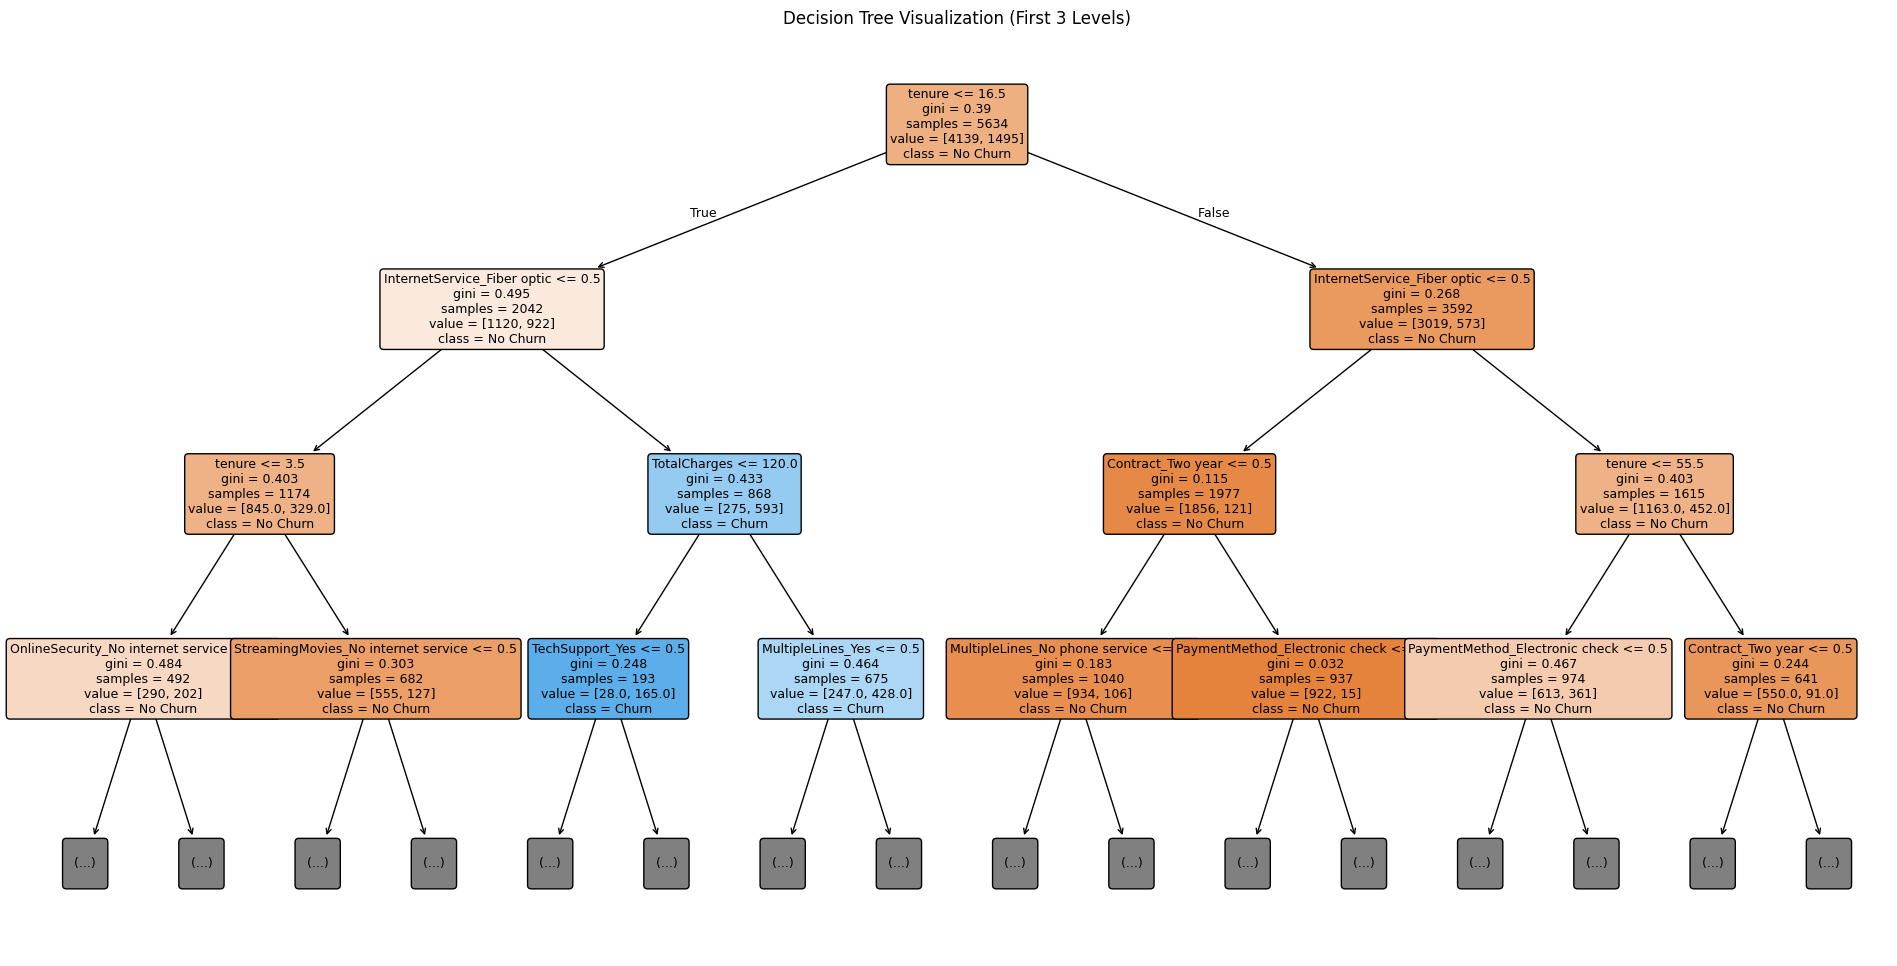

In [18]:
# Visualize the Decision Tree
plt.figure(figsize=(24, 12))
plot_tree(
    decision_tree,
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title('Decision Tree Visualization (First 3 Levels)')
plt.show()

In [19]:
# Decision Tree performance metrics
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
dt_test_accuracy = accuracy_score(y_test, y_test_pred_dt)
dt_train_precision = precision_score(y_train, y_train_pred_dt)
dt_test_precision = precision_score(y_test, y_test_pred_dt)
dt_train_recall = recall_score(y_train, y_train_pred_dt)
dt_test_recall = recall_score(y_test, y_test_pred_dt)
dt_train_f1 = f1_score(y_train, y_train_pred_dt)
dt_test_f1 = f1_score(y_test, y_test_pred_dt)

print("Decision Tree Performance")
print("=" * 40)
print("\nTraining Set:")
print(f"Accuracy : {dt_train_accuracy:.4f}")
print(f"Precision: {dt_train_precision:.4f}")
print(f"Recall   : {dt_train_recall:.4f}")
print(f"F1-score : {dt_train_f1:.4f}")
print("\nTesting Set:")
print(f"Accuracy : {dt_test_accuracy:.4f}")
print(f"Precision: {dt_test_precision:.4f}")
print(f"Recall   : {dt_test_recall:.4f}")
print(f"F1-score : {dt_test_f1:.4f}")

Decision Tree Performance

Training Set:
Accuracy : 0.8023
Precision: 0.6469
Recall   : 0.5612
F1-score : 0.6010

Testing Set:
Accuracy : 0.7942
Precision: 0.6312
Recall   : 0.5401
F1-score : 0.5821


In [20]:
# Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
# Train the model
random_forest.fit(X_train, y_train)
# Predictions on training and testing data
y_train_pred_rf = random_forest.predict(X_train)
y_test_pred_rf = random_forest.predict(X_test)
print("Random Forest model trained successfully.")
print("\nTraining predictions:", len(y_train_pred_rf))
print("Testing predictions:", len(y_test_pred_rf))

Random Forest model trained successfully.

Training predictions: 5634
Testing predictions: 1409


In [21]:
# Random Forest performance metrics

rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)

rf_train_precision = precision_score(y_train, y_train_pred_rf)
rf_test_precision = precision_score(y_test, y_test_pred_rf)

rf_train_recall = recall_score(y_train, y_train_pred_rf)
rf_test_recall = recall_score(y_test, y_test_pred_rf)

rf_train_f1 = f1_score(y_train, y_train_pred_rf)
rf_test_f1 = f1_score(y_test, y_test_pred_rf)

print("Random Forest Performance")
print("=" * 40)

print("\nTraining Set:")
print(f"Accuracy : {rf_train_accuracy:.4f}")
print(f"Precision: {rf_train_precision:.4f}")
print(f"Recall   : {rf_train_recall:.4f}")
print(f"F1-score : {rf_train_f1:.4f}")

print("\nTesting Set:")
print(f"Accuracy : {rf_test_accuracy:.4f}")
print(f"Precision: {rf_test_precision:.4f}")
print(f"Recall   : {rf_test_recall:.4f}")
print(f"F1-score : {rf_test_f1:.4f}")

Random Forest Performance

Training Set:
Accuracy : 0.8026
Precision: 0.7149
Recall   : 0.4261
F1-score : 0.5339

Testing Set:
Accuracy : 0.7928
Precision: 0.6830
Recall   : 0.4091
F1-score : 0.5117


In [22]:
# Testing with different Random Forest configurations

rf_configs = [
    {'n_estimators': 50, 'max_depth': 3},
    {'n_estimators': 100, 'max_depth': 3},
    {'n_estimators': 200, 'max_depth': 3},
    {'n_estimators': 50, 'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 5},
    {'n_estimators': 200, 'max_depth': 5},
    {'n_estimators': 50, 'max_depth': 8},
    {'n_estimators': 100, 'max_depth': 8},
    {'n_estimators': 200, 'max_depth': 8}
]

rf_results = []

for config in rf_configs:

    model = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rf_results.append({
        'n_estimators': config['n_estimators'],
        'max_depth': config['max_depth'],
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1-score': f1_score(y_test, predictions)
    })

# Convert results to DataFrame
rf_results_df = pd.DataFrame(rf_results)

# Sort by F1-score
rf_results_df = rf_results_df.sort_values(
    by='F1-score',
    ascending=False
)

display(rf_results_df)

,n_estimators,max_depth,Accuracy,Precision,Recall,F1-score
6,50,8,0.807665,0.678201,0.524064,0.591252
7,100,8,0.804116,0.673759,0.508021,0.579268
8,200,8,0.802697,0.672662,0.500000,0.573620
5,200,5,0.792761,0.679825,0.414439,0.514950
4,100,5,0.792761,0.683036,0.409091,0.511706
3,50,5,0.791341,0.678571,0.406417,0.508361
0,50,3,0.779986,0.675824,0.328877,0.442446
2,200,3,0.784244,0.708333,0.318182,0.439114
1,100,3,0.779986,0.700000,0.299465,0.419476


In [23]:
# Final tuned Random Forest
best_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=8,
    random_state=42
)

# Train the final model
best_rf.fit(X_train, y_train)

# Predictions
y_train_pred_best_rf = best_rf.predict(X_train)
y_test_pred_best_rf = best_rf.predict(X_test)

print("Final tuned Random Forest trained successfully.")

print("\nTraining predictions:", len(y_train_pred_best_rf))
print("Testing predictions:", len(y_test_pred_best_rf))

Final tuned Random Forest trained successfully.

Training predictions: 5634
Testing predictions: 1409


In [24]:
# Final tuned Random Forest performance

best_rf_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_best_rf
)

best_rf_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_best_rf
)

best_rf_train_precision = precision_score(
    y_train,
    y_train_pred_best_rf
)

best_rf_test_precision = precision_score(
    y_test,
    y_test_pred_best_rf
)

best_rf_train_recall = recall_score(
    y_train,
    y_train_pred_best_rf
)

best_rf_test_recall = recall_score(
    y_test,
    y_test_pred_best_rf
)

best_rf_train_f1 = f1_score(
    y_train,
    y_train_pred_best_rf
)

best_rf_test_f1 = f1_score(
    y_test,
    y_test_pred_best_rf
)

print("Final Tuned Random Forest Performance")
print("=" * 45)

print("\nTraining Set:")
print(f"Accuracy : {best_rf_train_accuracy:.4f}")
print(f"Precision: {best_rf_train_precision:.4f}")
print(f"Recall   : {best_rf_train_recall:.4f}")
print(f"F1-score : {best_rf_train_f1:.4f}")

print("\nTesting Set:")
print(f"Accuracy : {best_rf_test_accuracy:.4f}")
print(f"Precision: {best_rf_test_precision:.4f}")
print(f"Recall   : {best_rf_test_recall:.4f}")
print(f"F1-score : {best_rf_test_f1:.4f}")

Final Tuned Random Forest Performance

Training Set:
Accuracy : 0.8316
Precision: 0.7399
Recall   : 0.5632
F1-score : 0.6396

Testing Set:
Accuracy : 0.8077
Precision: 0.6782
Recall   : 0.5241
F1-score : 0.5913


In [25]:
# Extracting feature importance from the final Random Forest

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

# Sorting features by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Displaying all feature importances
display(feature_importance_df)

,Feature,Importance
0,tenure,0.215116
1,TotalCharges,0.135181
2,MonthlyCharges,0.098094
3,InternetService_Fiber optic,0.095047
4,Contract_Two year,0.065541
5,PaymentMethod_Electronic check,0.063865
6,OnlineSecurity_Yes,0.043562
7,Contract_One year,0.038004
8,TechSupport_Yes,0.026494
9,PaperlessBilling_Yes,0.019834


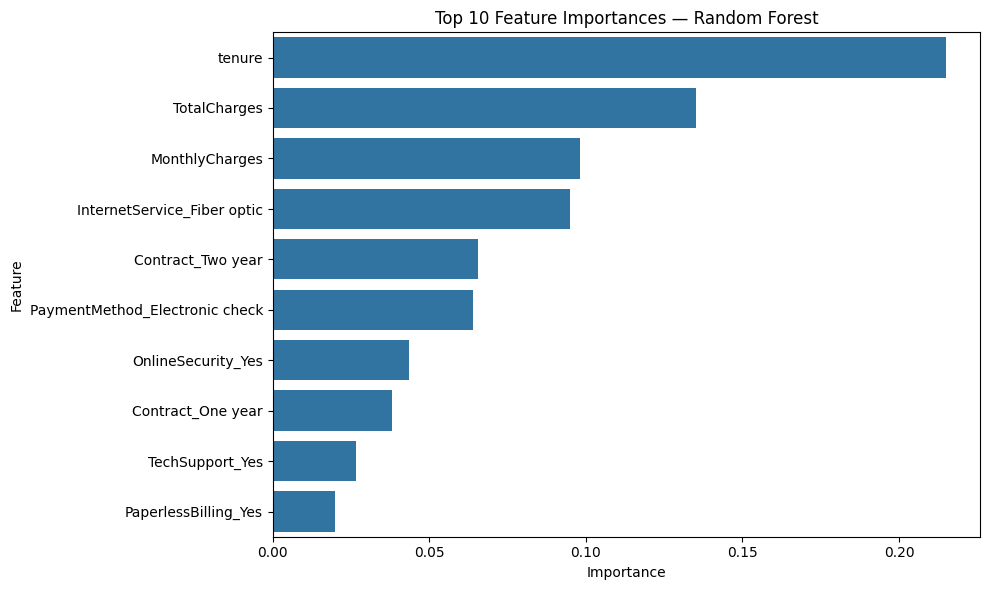

In [26]:
# Select top 10 most important features
top_features = feature_importance_df.head(10)
# Create feature importance bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [27]:
# Compare Decision Tree vs Final Tuned Random Forest

model_comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        dt_test_accuracy,
        best_rf_test_accuracy
    ],
    'Precision': [
        dt_test_precision,
        best_rf_test_precision
    ],
    'Recall': [
        dt_test_recall,
        best_rf_test_recall
    ],
    'F1-score': [
        dt_test_f1,
        best_rf_test_f1
    ]
})

# Display as percentages
model_comparison_display = model_comparison.copy()

for column in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    model_comparison_display[column] = (
        model_comparison_display[column] * 100
    ).round(2)

display(model_comparison_display)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,79.42,63.12,54.01,58.21
1,Random Forest,80.77,67.82,52.41,59.13


In [28]:
# Train vs Test Accuracy — Overfitting Check
overfitting_check = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest'
    ],
    'Train Accuracy': [
        dt_train_accuracy,
        best_rf_train_accuracy
    ],
    'Test Accuracy': [
        dt_test_accuracy,
        best_rf_test_accuracy
    ]
})
# Calculate the train-test gap
overfitting_check['Accuracy Gap'] = (
    overfitting_check['Train Accuracy']
    - overfitting_check['Test Accuracy']
)
# Convert to percentages
for column in ['Train Accuracy', 'Test Accuracy', 'Accuracy Gap']:
    overfitting_check[column] = (
        overfitting_check[column] * 100
    ).round(2)
display(overfitting_check)

,Model,Train Accuracy,Test Accuracy,Accuracy Gap
0,Decision Tree,80.23,79.42,0.81
1,Random Forest,83.16,80.77,2.39


In [29]:
import joblib
import os

# Google Drive folder path — UPDATE THIS
folder_path = '//content/drive/MyDrive/14 days of ML/TelecoChurn_DT+RF_Day5'

# Create folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

# Complete path for the saved model
model_path = os.path.join(
    folder_path,
    'telco_churn_random_forest.pkl'
)

# Save model + feature information
model_bundle = {
    'model': best_rf,
    'feature_columns': X_encoded.columns.tolist(),
    'target_mapping': {
        'No': 0,
        'Yes': 1
    }
}

joblib.dump(model_bundle, model_path)

print("Model saved successfully!")
print("Saved at:")
print(model_path)

Model saved successfully!
Saved at:
//content/drive/MyDrive/14 days of ML/TelecoChurn_DT+RF_Day5/telco_churn_random_forest.pkl
